/tmp/ipykernel_55/1668715370.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['main_genre'], order=target_genres, palette='viridis')


Vom multiplica genurile mai mici pana ajung la 1206 filme fiecare.
Noua distributie (Datele nu sunt taiate, ci duplicate unde e nevoie):
main_genre
Comedy             1206
Science Fiction    1206
Action             1206
Horror             1206
Drama              1206
Name: count, dtype: int64


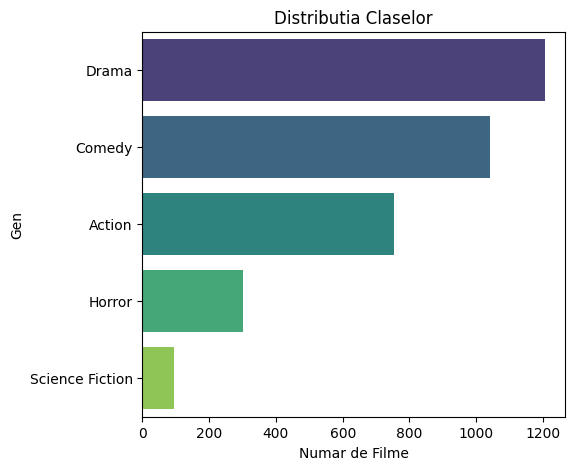

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

# Pentru procesare text (NLP)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Modelele alese
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

# Metrici de evaluare
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. INCARCAREA SI SELECTIA DATELOR
# ---------------------------------------------------------
df = pd.read_csv('/kaggle/input/tmdb-movie-metadata/tmdb_5000_movies.csv')
df = df[['original_title', 'overview', 'genres']]

# Verific daca am valori lipsa si le elimin (am gasit cateva descrieri goale)
df = df.dropna()

# 2. PREPROCESAREA COLOANEI 'GENRES'
# ---------------------------------------------------------
# Coloana 'genres' este in format JSON string. Creez o functie sa extrag primul gen listat.
# Ex: '[{"id": 28, "name": "Action"}, ...]'  -> devine -> "Action"
def extrage_primul_gen(text_json):
    genuri = json.loads(text_json)
    if genuri:
        return genuri[0]['name']
    else:
        return np.nan

# Aplic functia pe toata coloana
df['main_genre'] = df['genres'].apply(extrage_primul_gen)
df = df.dropna(subset=['main_genre']) # Elimin filmele care nu au niciun gen setat

target_genres = ['Drama', 'Comedy', 'Action', 'Horror', 'Science Fiction']

# GRAFIC DISTRIBUTIE GENURI 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(y=df['main_genre'], order=target_genres, palette='viridis')
plt.title('Distributia Claselor')
plt.xlabel('Numar de Filme')
plt.ylabel('Gen')

# 3. FILTRAREA SI ECHILIBRAREA (OVERSAMPLING)
# ---------------------------------------------------------
df_filtered = df[df['main_genre'].isin(target_genres)]

# Aflam care este cel mai des gen
max_samples = df_filtered['main_genre'].value_counts().max()
print(f"Vom multiplica genurile mai mici pana ajung la {max_samples} filme fiecare.")

df_balanced = pd.DataFrame()

for genre in target_genres:
    df_genre = df_filtered[df_filtered['main_genre'] == genre]
    
    # Daca genul are mai putine filme decat maximul, le multiplicam (resample cu replace=True)
    df_upsampled = resample(df_genre, 
                            replace=True,     # Permite duplicarea
                            n_samples=max_samples, # numarul maxim
                            random_state=42)
    
    df_balanced = pd.concat([df_balanced, df_upsampled])

# Amestec datele ca sa nu fie ordonate pe genuri
df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Noua distributie (Datele nu sunt taiate, ci duplicate unde e nevoie):")
print(df['main_genre'].value_counts())

In [3]:
# 4. VECTORIZAREA TEXTULUI (NLP)
# ---------------------------------------------------------
# Definesc vectorizatorul TF-IDF.
# Acesta va transforma textul in numere, ignorand cuvintele comune din engleza ('the', 'is', etc.)
# Am limitat la max_features=5000 pentru a nu avea o matrice prea mare si a pastra viteza de executie
# min_df=10: Ignora cuvintele care apar in mai putin de 10 filme. 
# Asta elimina numele de personaje (Kirk, Becky) si pastreaza temele generale.
tfidf = TfidfVectorizer(stop_words='english', 
                        max_features=5000, 
                        ngram_range=(1, 2), 
                        min_df=10)

# Construiesc matricea de trasaturi (X) si vectorul de etichete (y)
X = tfidf.fit_transform(df['overview'])
y = df['main_genre']

print(f"\nDimensiunea matricei de date (Filme x Cuvinte): {X.shape}")

# 5. IMPARTIREA IN TRAIN SI TEST
# ---------------------------------------------------------
# Impart datele: 80% pentru antrenare si 20% pentru testare
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Am impartit datele. Suntem gata de antrenare!")


Dimensiunea matricei de date (Filme x Cuvinte): (6030, 5000)
Am impartit datele. Suntem gata de antrenare!



Antrenez modelul SVM...
SVM antrenat cu succes.
Antrenez modelul DNN (poate dura cateva secunde)...
Iteration 1, loss = 1.55853619
Iteration 2, loss = 1.33376758
Iteration 3, loss = 1.03298205
Iteration 4, loss = 0.77035479
Iteration 5, loss = 0.57820651
Iteration 6, loss = 0.44257362
Iteration 7, loss = 0.34771383
Iteration 8, loss = 0.27952897
Iteration 9, loss = 0.22910973
Iteration 10, loss = 0.19055168
Iteration 11, loss = 0.16010438
Iteration 12, loss = 0.13553660
DNN antrenat cu succes.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


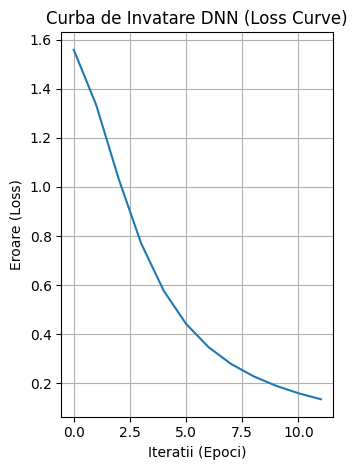


--- REZULTATE SVM ---
F1-Score SVM: 88.90%


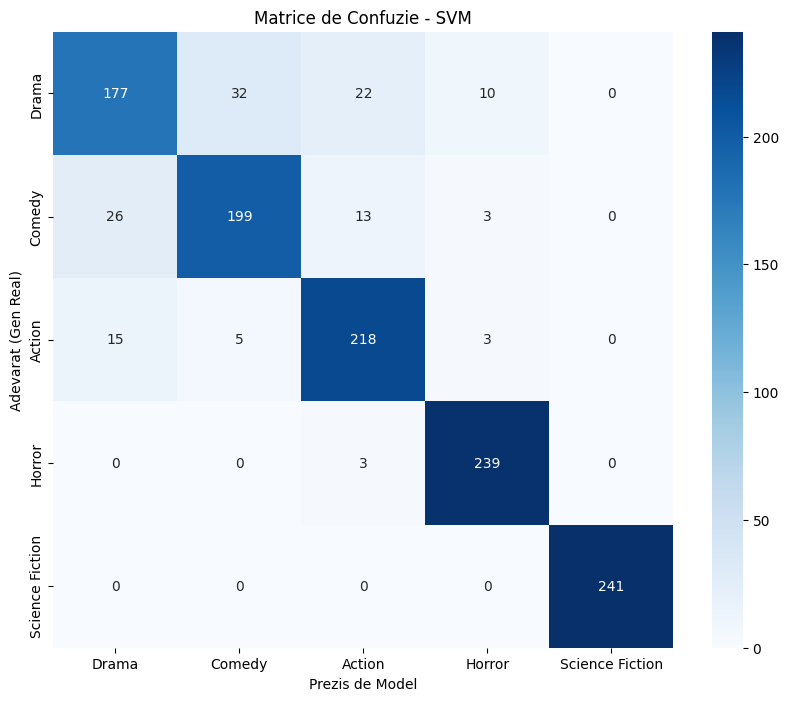

                 precision    recall  f1-score   support

          Drama       0.85      0.90      0.88       241
         Comedy       0.84      0.83      0.83       241
         Action       0.81      0.73      0.77       241
         Horror       0.94      0.99      0.96       242
Science Fiction       1.00      1.00      1.00       241

       accuracy                           0.89      1206
      macro avg       0.89      0.89      0.89      1206
   weighted avg       0.89      0.89      0.89      1206


--- REZULTATE DNN ---
F1-Score DNN: 89.94%


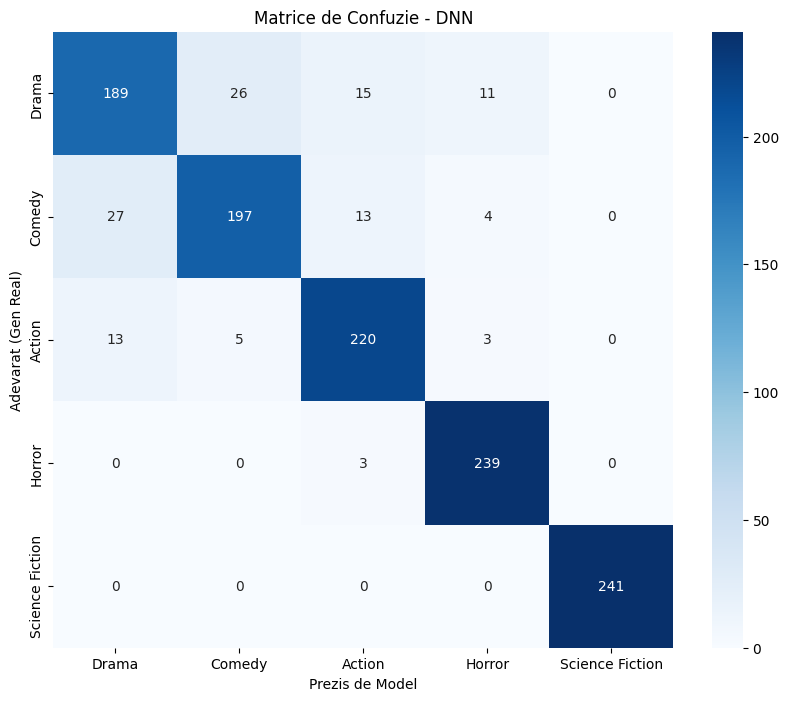

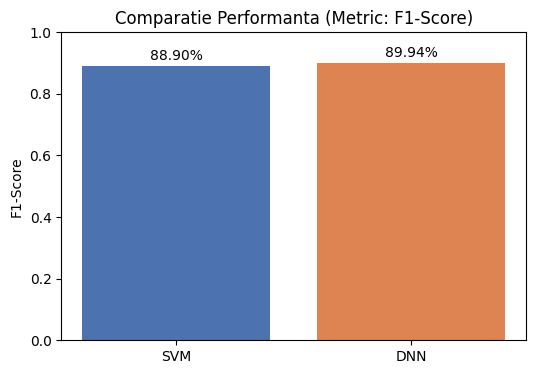

In [4]:
from sklearn.metrics import f1_score

# 6. IMPLEMENTAREA MODELELOR
# ---------------------------------------------------------

# --- MODEL 1: SVM (Support Vector Machine) ---
# Am ales LinearSVC deoarece este foarte eficient pentru date text cu multe dimensiuni
print("\nAntrenez modelul SVM...")
svm_model = LinearSVC(class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print("SVM antrenat cu succes.")

# --- MODEL 2: DNN (Deep Neural Network / MLP) ---
# Implementez un Multilayer Perceptron simplu
# Un strat ascuns cu 100 de neuroni ar trebui sa fie suficient
print("Antrenez modelul DNN (poate dura cateva secunde)...")
dnn_model = MLPClassifier(hidden_layer_sizes=(100,), solver='adam', max_iter=500, random_state=42, verbose=True)
dnn_model.fit(X_train, y_train)
y_pred_dnn = dnn_model.predict(X_test)
print("DNN antrenat cu succes.")

# CURBA DE INVATARE (LOSS CURVE) PENTRU DNN
plt.subplot(1, 2, 2)
plt.plot(dnn_model.loss_curve_)
plt.title('Curba de Invatare DNN (Loss Curve)')
plt.xlabel('Iteratii (Epoci)')
plt.ylabel('Eroare (Loss)')
plt.grid(True)

plt.tight_layout()
plt.show()

# 7. EVALUAREA SI VIZUALIZAREA REZULTATELOR
# ---------------------------------------------------------

def plot_confusion_matrix(y_true, y_pred, title):
    # Calculez matricea de confuzie
    cm = confusion_matrix(y_true, y_pred, labels=target_genres)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_genres, yticklabels=target_genres)
    plt.title(title)
    plt.ylabel('Adevarat (Gen Real)')
    plt.xlabel('Prezis de Model')
    plt.show()

# Calculez scorurile F1 (folosesc average='weighted' pentru a tine cont de suportul fiecarei clase)
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')
f1_dnn = f1_score(y_test, y_pred_dnn, average='weighted')

# --- REZULTATE SVM ---
print("\n--- REZULTATE SVM ---")
print(f"F1-Score SVM: {f1_svm:.2%}")
plot_confusion_matrix(y_test, y_pred_svm, "Matrice de Confuzie - SVM")
# Printez raportul detaliat (aici se vad Precision/Recall/F1 per clasa)
print(classification_report(y_test, y_pred_svm, target_names=target_genres))

# --- REZULTATE DNN ---
print("\n--- REZULTATE DNN ---")
print(f"F1-Score DNN: {f1_dnn:.2%}")
plot_confusion_matrix(y_test, y_pred_dnn, "Matrice de Confuzie - DNN")

# Grafic comparativ F1-SCORE
plt.figure(figsize=(6, 4))
bars = plt.bar(['SVM', 'DNN'], [f1_svm, f1_dnn], color=['#4c72b0', '#dd8452'])
plt.title('Comparatie Performanta (Metric: F1-Score)')
plt.ylim(0, 1) # Scara de la 0 la 1
plt.ylabel('F1-Score')

# Adaug valorile pe bare pentru claritate
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom')

plt.show()

In [7]:
# 8. INTERPRETAREA MODELULUI
# ---------------------------------------------------------
# Vreau sa vad ce cuvinte a invatat modelul ca fiind specifice fiecarui gen.
# Aceasta functie extrage "greutatile" (coeficientii) pe care modelul SVM le-a asignat cuvintelor.

def print_top_words(model, vectorizer, n_top_words=10):
    feature_names = vectorizer.get_feature_names_out()
    
    # Parcurg fiecare clasa (gen) invatata de model
    for i, class_label in enumerate(model.classes_):
        # Iau coeficientii pentru clasa curenta
        top_ids = np.argsort(model.coef_[i])[-n_top_words:]
        top_words = [feature_names[j] for j in top_ids]
        
        print(f"\nGenul: {class_label}")
        print(f"Cuvinte cheie: {', '.join(top_words)}")

print("\n--- CE A INVATAT MODELUL? ---")
print_top_words(svm_model, tfidf)


--- CE A INVATAT MODELUL? ---

Genul: Action
Cuvinte cheie: landscape, russian, terrorist, stolen, target, warrior, cop, race, assassin, kidnapped

Genul: Comedy
Cuvinte cheie: office, academy, fun, jane, tiny, comic, malcolm, lessons, doesn, comedy

Genul: Drama
Cuvinte cheie: husband, gradually, week, reconnect, memories, drama, life, revolution, section, journalist

Genul: Horror
Cuvinte cheie: horror, killer, demonic, begins, sinister, horrific, jigsaw, hell, terrifying, spirit

Genul: Science Fiction
Cuvinte cheie: discovery, turtles, shredder, procedure, time machine, hour, kirk, enterprise, origins, earth



--- INCEPE GENERAREA GRAFICULUI SPATIAL t-SNE ---
Acest pas poate dura 1-2 minute. Te rog asteapta...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.003s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 1000 samples in 0.167s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.544225
[t-SNE] KL divergence after 250 iterations with early exaggeration: 120.852280
[t-SNE] KL divergence after 1000 iterations: 2.534938
Reducerea dimensionalitatii a fost finalizata.
Graficul a fost generat!


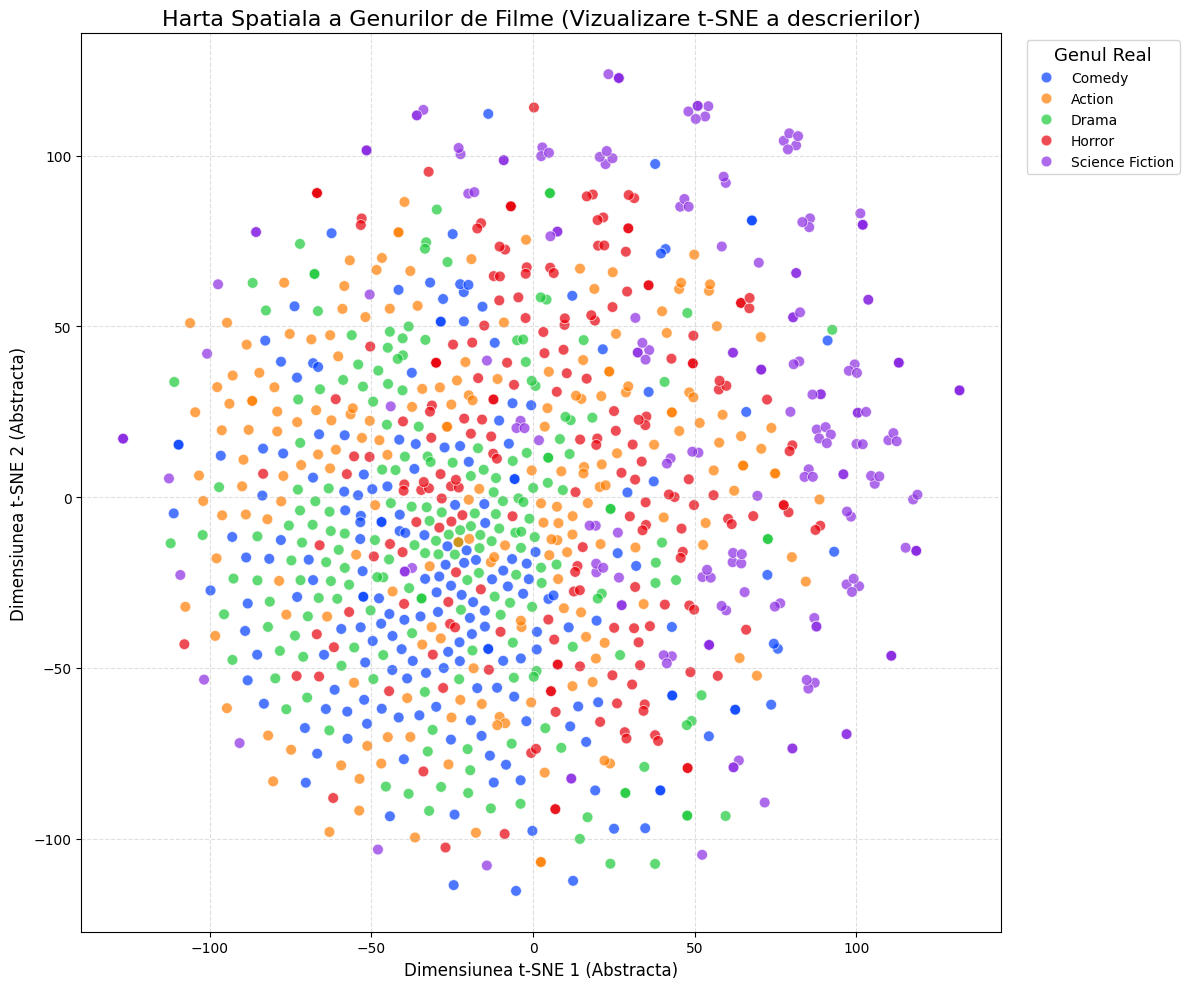

In [8]:
# ==============================================================================
# 9. VIZUALIZAREA SPATIALA A GENURILOR (t-SNE)
# ==============================================================================
from sklearn.manifold import TSNE

print("\n--- INCEPE GENERAREA GRAFICULUI SPATIAL t-SNE ---")
print("Acest pas poate dura 1-2 minute. Te rog asteapta...")

# --- Pasul 1: Pregatirea datelor ---
# Vom folosi datele de test (X_test) pentru vizualizare.
# t-SNE are nevoie de o matrice densa, nu una rara (sparse), deci folosim .toarray()
# Luam doar primele 1000 de filme din test pentru viteza 
X_for_viz = X_test[:1000].toarray()
y_for_viz = y_test[:1000]

# --- Pasul 2: Reducerea Dimensionalitatii (5000D -> 2D) ---
# n_components=2: Vrem 2 dimensiuni (X si Y)
# perplexity=30: Un parametru care controleaza cati "vecini" ia in considerare.
# random_state=42: Pentru rezultate reproductibile.
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=1)
X_2d = tsne.fit_transform(X_for_viz)

print("Reducerea dimensionalitatii a fost finalizata.")

# --- Pasul 3: Desenarea Graficului ---
plt.figure(figsize=(12, 10))

sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=y_for_viz,
    palette='bright', 
    alpha=0.7,        
    s=60              
)

plt.title('Harta Spatiala a Genurilor de Filme (Vizualizare t-SNE a descrierilor)', fontsize=16)
plt.xlabel('Dimensiunea t-SNE 1 (Abstracta)', fontsize=12)
plt.ylabel('Dimensiunea t-SNE 2 (Abstracta)', fontsize=12)
plt.legend(title='Genul Real', title_fontsize='13', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

print("Graficul a fost generat!")
plt.show()

Generez vizualizarea liniei de decizie SVM (Horror vs Comedy)...


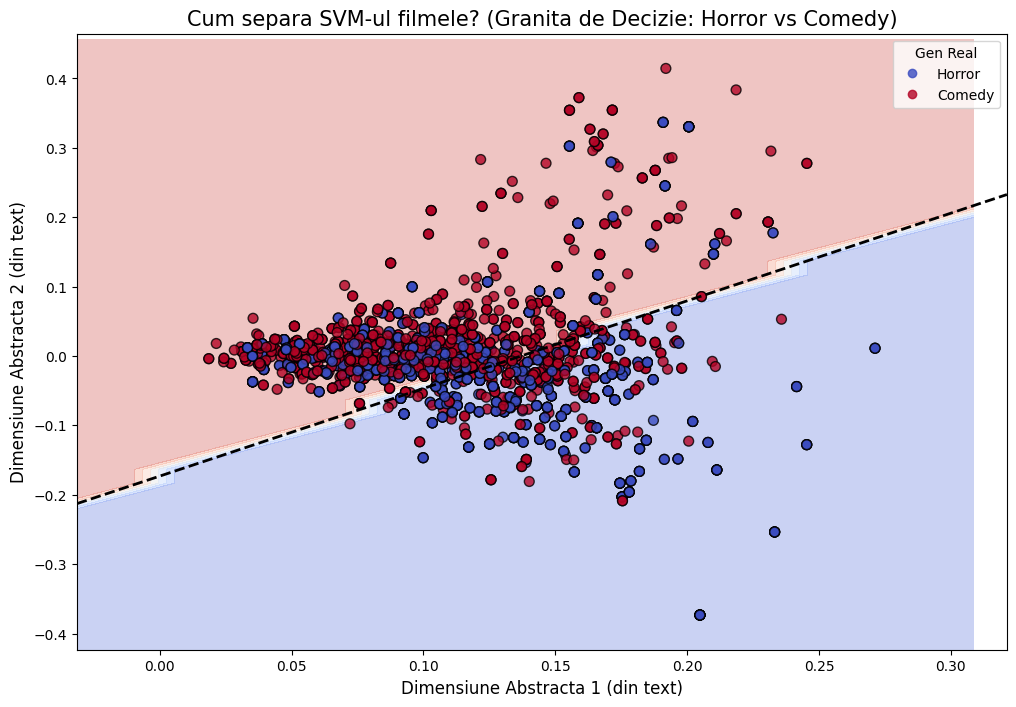

In [9]:
# ==============================================================================
# 10. CUM TRAGE SVM LINIA INTRE 2 GENURI?
# ==============================================================================
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC
import numpy as np 

print("Generez vizualizarea liniei de decizie SVM (Horror vs Comedy)...")

# 1. Selectam doar 2 genuri pentru a putea trage o linie clara
genuri_duel = ['Horror', 'Comedy']

# Creez masca (True/False)
mask = y.isin(genuri_duel)

# --- CORECTIA ESTE AICI ---
# X este o matrice rara (sparse), deci trebuie sa ii dam un array numpy
X_duel = X[mask.values]
y_duel = y[mask]

# Convertim etichetele in numere (0 si 1) pentru colorare
y_duel_num = y_duel.map({'Horror': 0, 'Comedy': 1})

# 2. Reducem la 2 dimensiuni
svd = TruncatedSVD(n_components=2, random_state=42)
X_duel_2d = svd.fit_transform(X_duel)

# 3. Antrenam un SVM simplu pe aceste date 2D
svm_viz = SVC(kernel='linear', C=1.0)
svm_viz.fit(X_duel_2d, y_duel_num)

# 4. Desenam "Harta" si Linia
plt.figure(figsize=(12, 8))

# --- Crearea grilei de fundal pentru a colora regiunile ---
h = .02 
x_min, x_max = X_duel_2d[:, 0].min() - 0.05, X_duel_2d[:, 0].max() + 0.05
y_min, y_max = X_duel_2d[:, 1].min() - 0.05, X_duel_2d[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Prezicem zona pentru fiecare punct din grila
Z = svm_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Coloram fundalul (Zonele de decizie)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

# --- Desenam punctele reale (Filmele) ---
scatter = plt.scatter(X_duel_2d[:, 0], X_duel_2d[:, 1], c=y_duel_num, 
                      cmap=plt.cm.coolwarm, edgecolors='k', s=50, alpha=0.8)

# Legenda si Etichete
handles, _ = scatter.legend_elements()
plt.legend(handles, genuri_duel, title="Gen Real", loc="upper right")
plt.title('Cum separa SVM-ul filmele? (Granita de Decizie: Horror vs Comedy)', fontsize=15)
plt.xlabel('Dimensiune Abstracta 1 (din text)', fontsize=12)
plt.ylabel('Dimensiune Abstracta 2 (din text)', fontsize=12)

# Desenam linia despartitoare
w = svm_viz.coef_[0]
a = -w[0] / w[1]
xx_line = np.linspace(x_min, x_max)
yy_line = a * xx_line - (svm_viz.intercept_[0]) / w[1]
plt.plot(xx_line, yy_line, 'k--', label='Granita Matematica (Hyperplane)', linewidth=2)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()